<a href="https://colab.research.google.com/github/nehabansal26/AI-for-Biological-Sciences/blob/main/1D_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##:: import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## Exact solution

In [ ]:
##:: training data: estimate the exact solution
L = 1 ## length of the cell chain
x_points = np.linspace(0,L,100) ## equally spaced points on the 1D cell chain
t_points = np.arange(0,1,0.001) ## equally spaced time points
exact_solution_list = [] ## list to store exact solution
for t in t_points:
    for x in x_points:
        exact_solution = np.exp(-np.pi**2*t)*np.sin(np.pi*x/L) ## formula for exact solution
        exact_solution_list.append([t,x,exact_solution])
exact_solution_df = pd.DataFrame(exact_solution_list, columns = ["Time","x","Exact Solution"]) ## exact solution list to dataframe conversion

Text(0.5, 1.0, 'Exact solution')

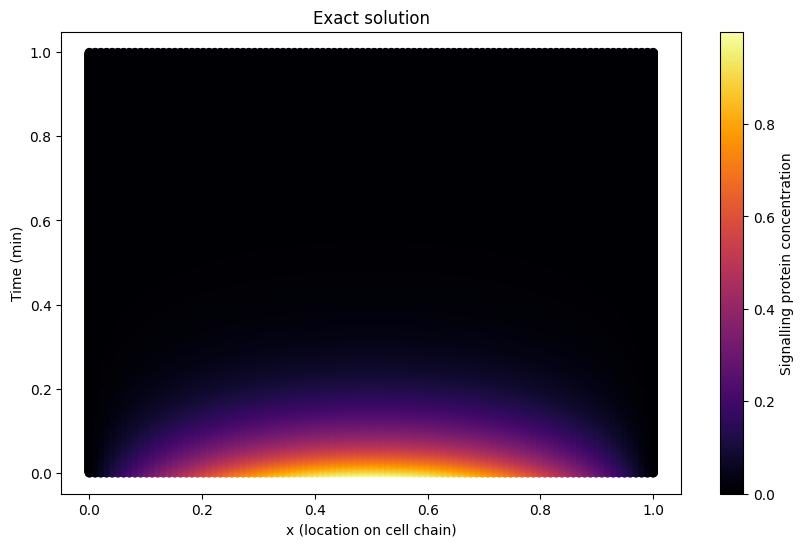

In [ ]:
##:: plot of exact solution with respect to location (x) and time (t)
plt.figure(figsize=(10,6))
plt.scatter(x=exact_solution_df['x'], y=exact_solution_df['Time'], c = exact_solution_df['Exact Solution'], cmap="inferno")
plt.colorbar(label="Signalling protein concentration")
plt.xlabel("x (location on cell chain)")
plt.ylabel("Time (min)")
plt.title("Exact solution")

## Physical informed neural netwrok solution (PINNs)

In [ ]:
##:: define the class for the neural network
class PINN1(nn.Module):
    def __init__(
        self,
        input_dim, ## dimension of input data, 2 as we have x and t
        output_dim, ## dimension of output, 1, as we predict p(x,t)
        hidden_layers=9, ## number of layers
        hidden_neurons=20, ## number of neurons in each layer
        activation=nn.Tanh ## activation function
    ):
        """
        Parameters
        ----------
        input_dim : int
            Number of input features
        output_dim : int
            Number of output neurons
        hidden_layers : int
            Number of hidden layers
        hidden_neurons : int
            Number of neurons per hidden layer
        activation : nn.Module
            Activation function class (e.g., nn.Tanh, nn.ReLU)
        """
        super().__init__()

        layers = [] ## list to store neural network layers

        # Input layer
        layers.append(nn.Linear(input_dim, hidden_neurons)) ## input layer takes x,t and project to higher dim
        layers.append(activation())

        # Hidden layers
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_neurons, hidden_neurons))
            layers.append(activation())

        # Output layer
        layers.append(nn.Linear(hidden_neurons, output_dim)) ## projecting the higher dim to 1, our output dim

        self.model = nn.Sequential(*layers) ## assembling the layers

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # smaller gain for PINNs
            nn.init.xavier_normal_(m.weight, gain=0.3)
            nn.init.zeros_(m.bias)

            # extra damping for output layer
            if m.out_features == 1:
                m.weight.data *= 0.1


    def forward(self, x):
        return self.model(x)

In [ ]:
##:: function to calculate mean square loss
def pinn_loss(pred, true):
    loss_ = torch.mean((pred - true) ** 2)
    return loss_

In [ ]:
def f(x, t, model):
    # numpy (n,) → torch (n,)
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True)
    t = torch.tensor(t, dtype=torch.float32, requires_grad=True)

    # (n, 2)
    x_t = torch.stack((x, t), dim=1)

    p = model(x_t)  # (n, 1) or (n,)

    # ∂p/∂t
    p_t = torch.autograd.grad(
        outputs=p,
        inputs=t,
        grad_outputs=torch.ones_like(p),
        create_graph=True
    )[0]

    # ∂p/∂x
    p_x = torch.autograd.grad(
        outputs=p,
        inputs=x,
        grad_outputs=torch.ones_like(p),
        create_graph=True
    )[0]

    # ∂²p/∂x²
    p_xx = torch.autograd.grad(
        outputs=p_x,
        inputs=x,
        grad_outputs=torch.ones_like(p_x),
        create_graph=True
    )[0]

    # Bioinfo#3
    f_res = p_t - p_xx
    return f_res

In [ ]:
##:: training data
x_points = np.linspace(0,L,1000) ## equally spaced points on the 1D cell chain
t_points = np.arange(0,1,0.01) ## equally spaced time points

x_t_bc = np.array([[x,t] for t in np.arange(0,1,0.01) for x in [0,L]]) ## boundary points
x_t_ic = np.array([[x,0] for x in x_points]) ## initial points
x_t_cp = np.array([[x,t] for t in t_points[1:] for x in np.random.choice(x_points[1:-1], size=100, replace=False)]) ## collocation points
x_cp = x_t_cp[:,0]
t_cp = x_t_cp[:,1]

y_bc = np.array([np.exp(-np.pi**2*t)*np.sin(np.pi*x/L) for x,t in x_t_bc]) ## exact solution at boundary points
y_ic = np.array([np.exp(-np.pi**2*t)*np.sin(np.pi*x/L) for x,t in x_t_ic]) ## exact solution at initial points
y_cp = np.array([0]*x_t_cp.shape[0]) ## exact solution at collocation points

In [ ]:
epochs = 100 ## number of iterations for neural network training

##:: define the neural network model architecture with parameter
model = PINN1(
    input_dim=2,
    output_dim=1,
    hidden_layers=15,
    hidden_neurons=20,
    activation=nn.Tanh
)

##:: optimizer for model training
optimizer = torch.optim.LBFGS(model.parameters(),
                              lr=1e-2,
                                max_iter=20,
                                max_eval=20,
                                history_size=50,
                                line_search_fn="strong_wolfe")

def closure():
    optimizer.zero_grad()

    # Boundary loss
    loss_bc = pinn_loss(
        model(torch.from_numpy(x_t_bc).float()),
        torch.from_numpy(y_bc).float()
    )

    # Initial condition loss
    loss_ic = pinn_loss(
        model(torch.from_numpy(x_t_ic).float()),
        torch.from_numpy(y_ic).float()
    )

    # PDE residual loss
    loss_cp = pinn_loss(
        f(x_cp, t_cp, model),
        torch.from_numpy(y_cp).float()
    )

    # Total loss
    lambda_bc = 3
    loss = lambda_bc*loss_bc + loss_ic + loss_cp

    loss.backward()
    return loss

loss_ls = []
# Phase 1: Adam
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for _ in range(epochs):
    loss = closure()
    loss_ls.append(loss.item())
    optimizer.step()

# Phase 2: LBFGS
optimizer = torch.optim.LBFGS(model.parameters(), lr = 1, max_iter=30,max_eval=20,history_size=50,line_search_fn="strong_wolfe")
for _ in range(50):
    loss = optimizer.step(closure)
    loss_ls.append(loss.item())

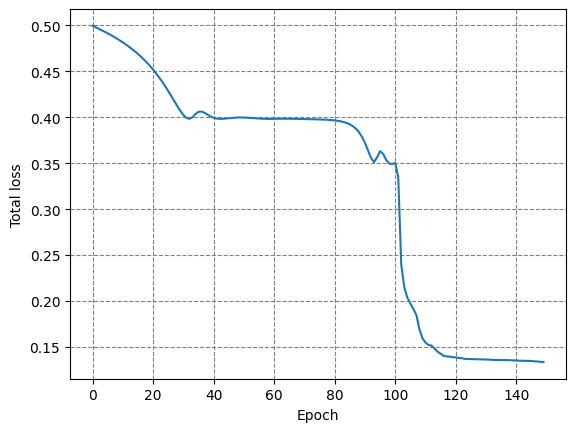

In [ ]:
##:: plotting the loss vs network training iteration
plt.plot(loss_ls)
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.grid(linestyle="--", color='grey')

## Comparison of exact solution and PINNs solution

In [ ]:
##:: test data points
x_test_points = np.linspace(0,L,100) ## equally spaced points on the 1D cell chain
t_test_points = np.arange(0,1,0.01) ## equally spaced time points
x_test = np.array([[x,t] for t in t_test_points for x in x_test_points])

##:: prediction on test data
model.eval()
with torch.no_grad():
    y_test_pred = model(torch.from_numpy(x_test).float())
y_test_pred_np = y_test_pred.detach().cpu().numpy().squeeze()

##:: exact solution on test data
y_test_actual =np.array([ np.exp(-np.pi**2*t)*np.sin(np.pi*x/L) for t in t_test_points for x in x_test_points])

##:: L2 error on test data
L2_error = np.mean(np.square(y_test_actual-y_test_pred_np))
print(f"L2 Error: {L2_error}")

L2 Error: 0.0019746574768488034


Text(0.5, 1.0, '|Exact - PINNs| solution')

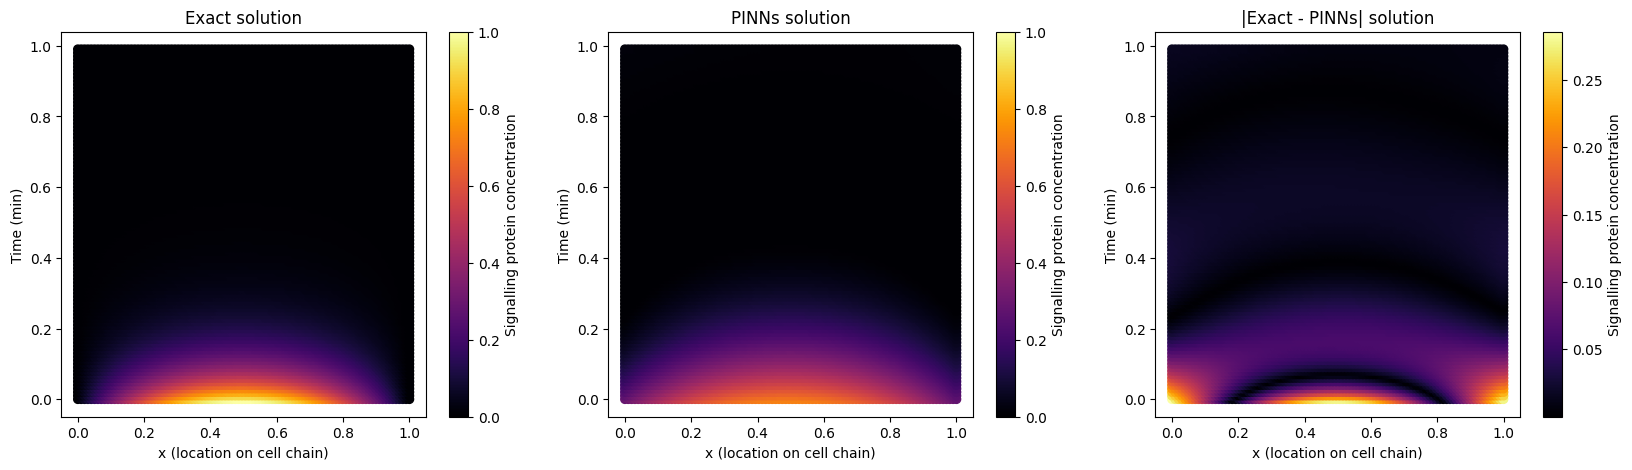

In [ ]:
##:: plot of exact solution and predicted solution with respect to location (x) and time (t)
plt.figure(figsize=(20,5))
plt.subplots_adjust(wspace=0.2, hspace=0.25)
plt.subplot(1,3,1)
plt.scatter(x=x_test[:,0], y=x_test[:,1], c = y_test_actual, cmap="inferno",vmax=1,vmin=0)
plt.colorbar(label="Signalling protein concentration")
plt.xlabel("x (location on cell chain)")
plt.ylabel("Time (min)")
plt.title("Exact solution")

plt.subplot(1,3,2)
plt.scatter(x=x_test[:,0], y=x_test[:,1], c = y_test_pred_np, cmap="inferno",vmax=1,vmin=0)
plt.colorbar(label="Signalling protein concentration")
plt.xlabel("x (location on cell chain)")
plt.ylabel("Time (min)")
plt.title("PINNs solution")

plt.subplot(1,3,3)
plt.scatter(x=x_test[:,0], y=x_test[:,1], c = np.abs(y_test_actual-y_test_pred_np), cmap="inferno")
plt.colorbar(label="Signalling protein concentration")
plt.xlabel("x (location on cell chain)")
plt.ylabel("Time (min)")
plt.title("|Exact - PINNs| solution")

In [ ]:
##:: data prep for L2 error with respect to time and x
test_data = pd.DataFrame(x_test,columns = ['x','t'])
test_data['pred'] = y_test_pred_np
test_data['actual'] = y_test_actual
test_data['pred_error'] = np.square(test_data['pred']-test_data['actual'])

Text(0.5, 1.0, 'L2 Error vs Location x')

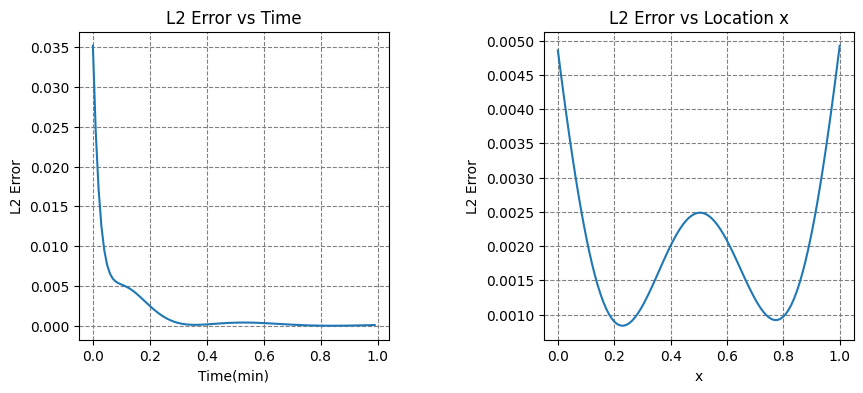

In [ ]:
plt.figure(figsize=(10,4))

##:: L2 error with time
plt.subplots_adjust(wspace=0.5)
plt.subplot(1,2,1)
plot_df = test_data.groupby('t').agg({'pred_error':'mean'}).reset_index()
plt.plot(plot_df.t, plot_df.pred_error)
plt.xlabel("Time(min)")
plt.ylabel("L2 Error")
plt.grid(linestyle="--", color='grey')
plt.title("L2 Error vs Time")

##:: L2 error with location on cell chain
plt.subplot(1,2,2)
plot_df = test_data.groupby('x').agg({'pred_error':'mean'}).reset_index()
plt.plot(plot_df.x, plot_df.pred_error)
plt.xlabel("x")
plt.ylabel("L2 Error")
plt.grid(linestyle="--", color='grey')
plt.title("L2 Error vs Location x")
